# Phase 4 — MP Filtering: Constructing the Cleaned Matrix

**Goal:** implement the filtering rule licensed by Phases 2–3, produce the cleaned
correlation/covariance matrices, and verify their properties. This is **Section 3.1
(Methodology)**; the code lives in the standalone module `mpfilter.py`, which every later
phase (including the rolling backtest) imports, so there is exactly one implementation.

## The filtering rule

Given the spectral decomposition $C = \sum_i \lambda_i v_i v_i^\top$ and the noise
threshold $\lambda_+ = \sigma^2 (1 + \sqrt q\,)^2$:

$$\lambda_i^{\mathrm{clean}} =
\begin{cases}
\lambda_i & \lambda_i \ge \lambda_+ \quad\text{(signal: untouched)}\\[4pt]
\bar\lambda \equiv \dfrac{1}{|\mathcal N|}\sum_{j \in \mathcal N} \lambda_j
& \lambda_i < \lambda_+ \quad\text{(noise: flattened)}
\end{cases}$$

then $C_f = V \Lambda^{\mathrm{clean}} V^\top$, followed by the unit-diagonal
renormalization $C_{\mathrm{clean}} = D_f^{-1/2}\, C_f\, D_f^{-1/2}$,
$D_f = \operatorname{diag}(C_f)$.

**Why flatten rather than delete.** Deleting noise modes (setting them to zero) would
destroy $\sum_{\mathcal N}\lambda_i$ of variance and leave the matrix singular. Flattening
*reattributes* that variance isotropically across the noise subspace: the total
(trace) is preserved exactly, and the matrix becomes *better* conditioned, since the
tiny eigenvalues — whose inverses explode inside $\Sigma^{-1}$ — are lifted to the
common average. The eigenvectors of the noise modes, which Phase 3 showed to be
GOE-random, are retained only as an orthonormal basis of the noise subspace; no
directional information within that subspace survives, which is precisely the point.

**Why renormalize the diagonal.** Filtering leaves $\operatorname{diag}(C_f)$ only
approximately 1. The symmetric renormalization restores exact unit diagonal (so each
stock keeps its own sample variance after rescaling to covariance) while preserving
positive definiteness. We report the size of the pre-renormalization deviation — it is
a small correction, not a hidden repair.

**Two thresholds travel forward** (from Phase 2): the KS-fitted band
($\hat\sigma^2 = 0.560$) as primary, the conservative market-mode band
($\sigma^2 = 0.762$) as robustness.

In [1]:
from pathlib import Path
import inspect, json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mpfilter

DATA_DIR = Path("data")
PALETTE = ["#0072B2", "#E69F00", "#009E73", "#CC79A7", "#56B4E9"]
plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "font.size": 10, "axes.titlesize": 11,
})

ev = np.load(DATA_DIR / "eigen_phase1.npz", allow_pickle=True)
lam_desc, V_desc = ev["lam"], ev["V"]
q, T, N = float(ev["q"]), int(ev["T"]), int(ev["N"])
fit = json.loads((DATA_DIR / "mp_fit_results.json").read_text())
s2_fit, s2_mkt = fit["sigma2_fit"], fit["sigma2_market"]

Rs = pd.read_parquet(DATA_DIR / "returns_std.parquet")
tickers = list(Rs.columns)
C = (Rs.values.T @ Rs.values) / T
np.save(DATA_DIR / "C_raw.npy", C)
print(f"N={N}, T={T}; thresholds: fitted sigma2={s2_fit}, market sigma2={s2_mkt:.4f}")
print("\n--- canonical implementation (mpfilter.py) ---\n")
print(inspect.getsource(mpfilter.clean_correlation))

N=548, T=1236; thresholds: fitted sigma2=0.56, market sigma2=0.7623

--- canonical implementation (mpfilter.py) ---

def clean_correlation(C, T, sigma2="market"):
    """MP-filter a correlation matrix. Returns (C_clean, info).

    sigma2: "market" -> 1 - lam_max/N (per-window, no fitting required),
            "naive"  -> 1.0,
            float    -> explicit value (e.g. a KS-fitted sigma2).
    """
    C = np.asarray(C, float)
    N = C.shape[0]
    lam, V = np.linalg.eigh(C)                       # ascending
    if sigma2 == "market":
        s2 = 1.0 - lam[-1] / N
    elif sigma2 == "naive":
        s2 = 1.0
    else:
        s2 = float(sigma2)
    lp = mp_lambda_plus(N, T, s2)

    noise = lam < lp
    lam_clean = lam.copy()
    if noise.any():
        lam_clean[noise] = lam[noise].mean()
    C_f = (V * lam_clean) @ V.T

    d = np.sqrt(np.diag(C_f))
    C_clean = C_f / np.outer(d, d)
    np.fill_diagonal(C_clean, 1.0)

    info = {
        "sigma2": float(s2),
        "lambda_plu

## 1. Apply the filter and verify every claimed property

Checks: trace preservation (exact), unit diagonal (exact after renormalization, small
before), symmetry, positive definiteness, market-mode preservation, and the conditioning
improvement that is the operational purpose of the exercise.

In [2]:
def audit(C_clean, info, label):
    lam_c = np.linalg.eigvalsh(C_clean)
    v1 = V_desc[:, 0]
    checks = {
        "trace(C_clean)": C_clean.trace(),
        "trace preserved (pre-renorm)": info["trace_after_filter"],
        "max |diag-1| pre-renorm": info["max_diag_dev_pre_renorm"],
        "symmetric": bool(np.allclose(C_clean, C_clean.T)),
        "min eigenvalue": lam_c[0],
        "kappa before": lam_desc[0] / lam_desc[-1],
        "kappa after": lam_c[-1] / lam_c[0],
        "market mode preserved  v1'Cv1": float(v1 @ C_clean @ v1),
        "n_signal / n_noise": f"{info['n_signal']} / {info['n_noise']}",
        "noise floor (mean of flattened)": info["noise_mean"],
        "lambda_plus used": info["lambda_plus"],
    }
    print(f"=== {label} ===")
    for k, v in checks.items():
        print(f"  {k:34s} {v:.6g}" if isinstance(v, float) else f"  {k:34s} {v}")
    print()
    return lam_c

C_clean_fit, info_fit = mpfilter.clean_correlation(C, T, sigma2=s2_fit)
C_clean_mkt, info_mkt = mpfilter.clean_correlation(C, T, sigma2=s2_mkt)

lam_cf = audit(C_clean_fit, info_fit, f"fitted threshold (sigma2={s2_fit})")
lam_cm = audit(C_clean_mkt, info_mkt, f"market threshold (sigma2={s2_mkt:.4f})")

print(f"lambda_1 raw = {lam_desc[0]:.2f} (for reference against v1'Cv1 above)")

=== fitted threshold (sigma2=0.56) ===
  trace(C_clean)                     548
  trace preserved (pre-renorm)       548
  max |diag-1| pre-renorm            0.31671
  symmetric                          True
  min eigenvalue                     0.435144
  kappa before                       3007.93
  kappa after                        294.59
  market mode preserved  v1'Cv1      127.826
  n_signal / n_noise                 56 / 492
  noise floor (mean of flattened)    0.56774
  lambda_plus used                   1.55404

=== market threshold (sigma2=0.7623) ===
  trace(C_clean)                     548
  trace preserved (pre-renorm)       548
  max |diag-1| pre-renorm            0.365349
  symmetric                          True
  min eigenvalue                     0.476395
  kappa before                       3007.93
  kappa after                        268.297
  market mode preserved  v1'Cv1      127.324
  n_signal / n_noise                 22 / 526
  noise floor (mean of flattened)    

## 2. The rank-deficient case: the filter as regularizer

Phase 1 showed a 252-day window gives a *singular* covariance (rank 248 of 548). The same
filter, applied inside that window, lifts the 300 zero modes to the common noise average —
the cleaned matrix is invertible and the minimum-variance problem becomes well-posed.
This is the mechanism the backtest (Phase 7) relies on.

In [3]:
R = pd.read_parquet(DATA_DIR / "returns_daily.parquet")
win = R.iloc[-252:].values
Sig_raw, Sig_clean, info_w = mpfilter.clean_covariance(win, sigma2="market")

lw_raw = np.linalg.eigvalsh(Sig_raw)
lw_cln = np.linalg.eigvalsh(Sig_clean)
print(f"252-day window (q = {N/252:.2f}):")
print(f"  raw:     rank {int((lw_raw > lw_raw[-1]*1e-10).sum())} of {N}, "
      f"min eig {lw_raw[0]:.2e}  -> singular")
print(f"  cleaned: min eig {lw_cln[0]:.2e}, kappa = {lw_cln[-1]/lw_cln[0]:.1f}  -> invertible")
print(f"  signal modes kept in-window: {info_w['n_signal']}  "
      f"(lambda_+ = {info_w['lambda_plus']:.3f}, sigma2 = {info_w['sigma2']:.3f})")
print(f"  trace check: raw {np.trace(Sig_raw):.6e} vs cleaned {np.trace(Sig_clean):.6e}")

252-day window (q = 2.17):
  raw:     rank 248 of 548, min eig -1.70e-17  -> singular
  cleaned: min eig 6.96e-05, kappa = 1029.2  -> invertible
  signal modes kept in-window: 12  (lambda_+ = 4.466, sigma2 = 0.729)
  trace check: raw 2.741197e-01 vs cleaned 2.741197e-01


## 3. Figure — what the filter does

(a) Sorted spectra before/after: signal modes untouched, noise bulk flattened to a floor.
(b) Off-diagonal correlations before vs. after (hexbin): the central mass hugs the
diagonal (mean correlation essentially unchanged), the dispersion tightens, and —
importantly — the *largest* pairwise correlations are partially attenuated. A pair
correlated at 0.8 owes much of that to a localized two-stock mode sitting near or inside
the bulk, which the filter flattens. This is an inherent trade-off of spectral cleaning,
stated honestly here and revisited in the Discussion.

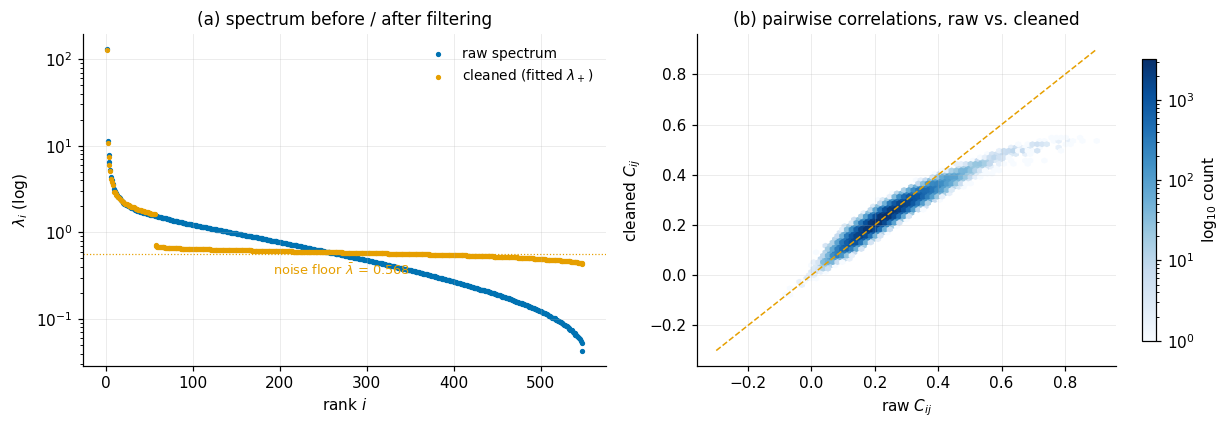

off-diagonal summary: mean raw 0.2274 -> cleaned 0.2262; std raw 0.0743 -> cleaned 0.0628
relative Frobenius change ||C_clean - C||_F / ||C||_F = 0.0989


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11.4, 4.0))

idx = np.arange(1, N + 1)
axes[0].scatter(idx, lam_desc, s=6, color=PALETTE[0], label="raw spectrum")
axes[0].scatter(idx, lam_cf[::-1], s=6, color=PALETTE[1], label="cleaned (fitted $\\lambda_+$)")
axes[0].set_yscale("log")
axes[0].axhline(info_fit["noise_mean"], color=PALETTE[1], lw=0.8, ls=":")
axes[0].annotate(f"noise floor $\\bar\\lambda$ = {info_fit['noise_mean']:.3f}",
                 xy=(N*0.35, info_fit["noise_mean"]), xytext=(0, -14),
                 textcoords="offset points", fontsize=8.5, color=PALETTE[1])
axes[0].set_xlabel("rank $i$"); axes[0].set_ylabel("$\\lambda_i$ (log)")
axes[0].set_title("(a) spectrum before / after filtering")
axes[0].legend(frameon=False, fontsize=9)

iu = np.triu_indices(N, k=1)
hb = axes[1].hexbin(C[iu], C_clean_fit[iu], gridsize=80, bins="log", cmap="Blues",
                    extent=(-0.3, 0.9, -0.3, 0.9))
axes[1].plot([-0.3, 0.9], [-0.3, 0.9], color=PALETTE[1], lw=1.0, ls="--")
axes[1].set_xlabel("raw $C_{ij}$"); axes[1].set_ylabel("cleaned $C_{ij}$")
axes[1].set_title("(b) pairwise correlations, raw vs. cleaned")
fig.colorbar(hb, ax=axes[1], label="log$_{10}$ count", shrink=0.85)

fig.tight_layout()
fig.savefig(DATA_DIR / "fig_phase4_filter.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"off-diagonal summary: mean raw {C[iu].mean():.4f} -> cleaned {C_clean_fit[iu].mean():.4f}; "
      f"std raw {C[iu].std():.4f} -> cleaned {C_clean_fit[iu].std():.4f}")
print(f"relative Frobenius change ||C_clean - C||_F / ||C||_F = "
      f"{np.linalg.norm(C_clean_fit - C) / np.linalg.norm(C):.4f}")

In [5]:
np.save(DATA_DIR / "C_clean_fitted.npy", C_clean_fit)
np.save(DATA_DIR / "C_clean_market.npy", C_clean_mkt)

out = {
    "fitted": info_fit, "market": info_mkt,
    "kappa_raw": float(lam_desc[0] / lam_desc[-1]),
    "kappa_clean_fitted": float(lam_cf[-1] / lam_cf[0]),
    "kappa_clean_market": float(lam_cm[-1] / lam_cm[0]),
    "frobenius_rel_change_fitted": float(np.linalg.norm(C_clean_fit - C) / np.linalg.norm(C)),
    "window252_demo": {k: (float(v) if isinstance(v, (int, float)) and not isinstance(v, bool) else v)
                       for k, v in info_w.items()},
}
(DATA_DIR / "phase4_results.json").write_text(json.dumps(out, indent=2))
print(json.dumps(out, indent=2))

{
  "fitted": {
    "sigma2": 0.56,
    "lambda_plus": 1.5540447569274474,
    "n_noise": 492,
    "n_signal": 56,
    "noise_mean": 0.567740394056871,
    "max_diag_dev_pre_renorm": 0.31671004155427185,
    "trace_after_filter": 548.0
  },
  "market": {
    "sigma2": 0.762344,
    "lambda_plus": 2.1155655288841033,
    "n_noise": 526,
    "n_signal": 22,
    "noise_mean": 0.6451633156544999,
    "max_diag_dev_pre_renorm": 0.36534909242699487,
    "trace_after_filter": 548.0
  },
  "kappa_raw": 3007.934267346975,
  "kappa_clean_fitted": 294.5900418947137,
  "kappa_clean_market": 268.29697412848174,
  "frobenius_rel_change_fitted": 0.0988671515025115,
  "window252_demo": {
    "sigma2": 0.7292708288334953,
    "lambda_plus": 4.465989162251225,
    "n_noise": 536.0,
    "n_signal": 12.0,
    "noise_mean": 0.6003309424682739,
    "max_diag_dev_pre_renorm": 0.35063967043906086,
    "trace_after_filter": 547.9999999999998
  }
}


In [6]:
draft = f'''Licensed by the two validation layers of Sections 5.1-5.2, we clean the
correlation matrix by flattening its noise spectrum. Every eigenvalue below the threshold
lambda_+ = sigma2 (1 + sqrt(q))^2 is replaced by the average of all sub-threshold
eigenvalues, eigenvectors are left untouched, and the reconstructed matrix is
symmetrically renormalized to unit diagonal. Flattening -- rather than deleting -- the
noise modes preserves the trace exactly: total variance is reattributed isotropically
across the noise subspace, never created or destroyed (the pre-renormalization diagonal
deviates from unity by at most {info_fit['max_diag_dev_pre_renorm']:.3f}). With the
fitted threshold, {info_fit['n_signal']} signal modes are retained and
{info_fit['n_noise']} noise modes are flattened to a common floor of
{info_fit['noise_mean']:.3f}; the condition number of the correlation matrix falls from
{lam_desc[0]/lam_desc[-1]:.0f} to {lam_cf[-1]/lam_cf[0]:.0f}. Pairwise structure is
modified conservatively overall (relative Frobenius change of
{np.linalg.norm(C_clean_fit - C)/np.linalg.norm(C):.1%}; mean off-diagonal correlation
{C[iu].mean():.3f} -> {C_clean_fit[iu].mean():.3f}), with one deliberate exception:
the largest pairwise correlations are partially attenuated, because a pair correlated
far above the market level owes much of that excess to a localized two-stock mode
lying near or inside the noise band, which the filter flattens along with the rest of
the bulk. Whether suppressing such pair-specific structure helps or hurts
out-of-sample is precisely what the backtest adjudicates. Crucially, the same rule regularizes the
rank-deficient case: within a 252-day estimation window (q = {N/252:.2f} > 1), the
{N} - 252 zero eigenvalues fall below lambda_+ and are lifted to the noise floor,
rendering Sigma_clean invertible where Sigma_raw is singular -- the property the
out-of-sample backtest of Section 5.4 exploits. All experiments use the single
implementation in mpfilter.py; the conservative market-mode threshold
(sigma2 = {s2_mkt:.3f}, {info_mkt['n_signal']} signal modes) is carried alongside as a
robustness variant.'''

print(draft)
(DATA_DIR / "section31_filter_draft.md").write_text(draft)
print("\nsaved -> data/section31_filter_draft.md")

Licensed by the two validation layers of Sections 5.1-5.2, we clean the
correlation matrix by flattening its noise spectrum. Every eigenvalue below the threshold
lambda_+ = sigma2 (1 + sqrt(q))^2 is replaced by the average of all sub-threshold
eigenvalues, eigenvectors are left untouched, and the reconstructed matrix is
symmetrically renormalized to unit diagonal. Flattening -- rather than deleting -- the
noise modes preserves the trace exactly: total variance is reattributed isotropically
across the noise subspace, never created or destroyed (the pre-renormalization diagonal
deviates from unity by at most 0.317). With the
fitted threshold, 56 signal modes are retained and
492 noise modes are flattened to a common floor of
0.568; the condition number of the correlation matrix falls from
3008 to 295. Pairwise structure is
modified conservatively overall (relative Frobenius change of
9.9%; mean off-diagonal correlation
0.227 -> 0.226), with one deliberate exception:
the largest pairwise 

## What to write where

- **Section 3.1 (Methodology):** the draft above, plus the filtering-rule math block from
  this notebook's header.
- **Figure for the appendix or main text:** `fig_phase4_filter.png` — panel (b) is an
  unusually direct visualization of what cleaning does to actual correlations.
- **Artifacts:** `C_clean_fitted.npy`, `C_clean_market.npy`, `C_raw.npy`,
  `phase4_results.json`; the reusable filter is `mpfilter.py` (imported, not copied, by
  Phases 5–7).